# Principal Component Analysis (PCA) — Iris Dataset
## Reducción de Dimensiones y Análisis de Componentes Principales

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** Iris — 150 observations × 4 features (loaded from public URL)

**Objective / Objetivo:**  
EN · Apply PCA to reduce the Iris dataset from 4 dimensions to 2 principal components, analyze variance explained, loadings, and visualize the full biplot: scree plot, loadings heatmap, observations map, factors map, and combined biplot.

ES · Aplicar PCA para reducir el dataset Iris de 4 dimensiones a 2 componentes principales, analizar varianza explicada y loadings, y visualizar el biplot completo: scree plot, heatmap de loadings, mapa de observaciones, mapa de factores y biplot combinado.

**Techniques / Técnicas:** PCA · Scree Plot · Loadings Analysis · Biplot · Variance Explained  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib`

---

# Paso 1: Importar librerías y cargar el dataset

In [2]:
# ============================================================
# IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Paso 2: Cargar el Dataset desde GitHub

In [4]:
# ============================================================
# CARGA DEL DATASET IRIS DESDE LA URL PROPORCIONADA
# ============================================================

url = "https://gist.githubusercontent.com/netj/8836201/raw/iris.csv"

df = pd.read_csv(url)

df.head(10)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


# Paso 3: Exploración Inicial del Dataset

In [9]:
# ============================================================
# EXPLORACIÓN ESTADÍSTICA DEL DATASET
# ============================================================

print('\n' + '─' * 55)
print(" INFORMACIÓN GENERAL DEL DATASET:")
print('─' * 55)
print(df.info())

print('\n' + '─' * 55)
print(" ESTADÍSTICAS DESCRIPTIVAS:")
print('─' * 55)
print(df.describe().round(3))

print('\n' + '─' * 55)
print(" DISTRIBUCIÓN POR ESPECIE:")
print('─' * 55)
print(df['variety'].value_counts())

print('\n' + '─' * 55)
print(" VALORES NULOS POR COLUMNA:")
print('─' * 55)
print(df.isnull().sum())

print('\n' + '─' * 55)
print(" FILAS DUPLICADAS:")
print('─' * 55)
print(df.duplicated().sum())
print(df[df.duplicated(keep=False)])


───────────────────────────────────────────────────────
 INFORMACIÓN GENERAL DEL DATASET:
───────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

───────────────────────────────────────────────────────
 ESTADÍSTICAS DESCRIPTIVAS:
───────────────────────────────────────────────────────
       sepal.length  sepal.width  petal.length  petal.width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min       

# Paso 4: Preprocesamiento - Estandarización

In [10]:
# ============================================================
# ESTANDARIZACIÓN DE LOS DATOS (REQUISITO PREVIO AL PCA)
# ============================================================

# Separar características numéricas de la variable objetivo
features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
X = df[features].values
y = df['variety'].values

# Estandarizar los datos (media=0, std=1)
X_scaled = StandardScaler().fit_transform(X)

# Verificar estandarización
df_scaled = pd.DataFrame(X_scaled, columns=features)
print("─" * 55)
print(" DATOS ESTANDARIZADOS - ESTADÍSTICAS:")
print("─" * 55)
print(df_scaled.describe().round(4))
print()
print("✓ Media ≈ 0 y Desviación Estándar ≈ 1")

───────────────────────────────────────────────────────
 DATOS ESTANDARIZADOS - ESTADÍSTICAS:
───────────────────────────────────────────────────────
       sepal.length  sepal.width  petal.length  petal.width
count      150.0000     150.0000      150.0000     150.0000
mean        -0.0000      -0.0000       -0.0000      -0.0000
std          1.0034       1.0034        1.0034       1.0034
min         -1.8700      -2.4339       -1.5676      -1.4471
25%         -0.9007      -0.5924       -1.2266      -1.1838
50%         -0.0525      -0.1320        0.3365       0.1325
75%          0.6745       0.5586        0.7628       0.7907
max          2.4920       3.0908        1.7858       1.7121

✓ Media ≈ 0 y Desviación Estándar ≈ 1


# Paso 5: Aplicar PCA con 2 Componentes

In [22]:
# ============================================================
# APLICACIÓN DE PCA CON 2 COMPONENTES PRINCIPALES
# ============================================================

# Aplicar PCA con todos los componentes primero (para análisis completo)
pca_full = PCA()
pca_full.fit(X_scaled)

# PCA con 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ─── Varianza explicada ───
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

print("=" * 55)
print("RESULTADOS DEL ANÁLISIS PCA")
print("=" * 55)

print("\n VARIANZA EXPLICADA POR CADA COMPONENTE:")
print('─' * 50)
for i, comp in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {comp*100:4.2f}%")

print("\n VARIANZA ACUMULADA:")
print('─' * 50)
for i, acum in enumerate(varianza_acumulada):
    print(f"  PC1 a PC{i+1}: {acum*100:.2f}%")

print('\n' + '─' * 50)
print(" RESUMEN - DOS PRIMEROS COMPONENTES (PC1 + PC2):")
print('─' * 50)
print(f"  ▸ PC1 explica: {varianza_explicada[0]*100:.2f}% de la varianza")
print(f"  ▸ PC2 explica: {varianza_explicada[1]*100:.2f}% de la varianza")
print(f"  ▸ TOTAL (PC1+PC2): {sum(varianza_explicada)*100:.2f}% de la varianza")
print()
print("✓ Con solo 2 componentes se captura la mayoría de la información del dataset original (4D → 2D)")

RESULTADOS DEL ANÁLISIS PCA

 VARIANZA EXPLICADA POR CADA COMPONENTE:
──────────────────────────────────────────────────
  PC1: 72.96%
  PC2: 22.85%
  PC3: 3.67%
  PC4: 0.52%

 VARIANZA ACUMULADA:
──────────────────────────────────────────────────
  PC1 a PC1: 72.96%
  PC1 a PC2: 95.81%
  PC1 a PC3: 99.48%
  PC1 a PC4: 100.00%

──────────────────────────────────────────────────
 RESUMEN - DOS PRIMEROS COMPONENTES (PC1 + PC2):
──────────────────────────────────────────────────
  ▸ PC1 explica: 72.96% de la varianza
  ▸ PC2 explica: 22.85% de la varianza
  ▸ TOTAL (PC1+PC2): 95.81% de la varianza

✓ Con solo 2 componentes se captura la mayoría de la información del dataset original (4D → 2D)


# Paso 6: Análisis de Loadings (Pesos de Variables)

In [23]:
# ============================================================
# ANÁLISIS DE LOADINGS - CONTRIBUCIÓN DE CADA VARIABLE
# ============================================================

loadings = pca.components_

print('=' * 55)
print(" MATRIZ DE LOADINGS (COMPONENTES PRINCIPALES)")
print('=' * 55)
print()

df_loadings = pd.DataFrame(
    loadings.T,
    columns=['PC1', 'PC2'],
    index=features
)

print(" PESOS DE CADA VARIABLE EN LOS COMPONENTES:")
print('─' * 45)
print(df_loadings.round(4))

 MATRIZ DE LOADINGS (COMPONENTES PRINCIPALES)

 PESOS DE CADA VARIABLE EN LOS COMPONENTES:
─────────────────────────────────────────────
                 PC1     PC2
sepal.length  0.5211  0.3774
sepal.width  -0.2693  0.9233
petal.length  0.5804  0.0245
petal.width   0.5649  0.0669


# Paso 7: Crear DataFrame con Resultados PCA

In [49]:
# ============================================================
# DATAFRAME CON COORDENADAS PCA
# ============================================================

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['variety'] = y

# Agregar datos originales para análisis posterior
df_pca['sepal.length'] = df['sepal.length'].values
df_pca['sepal.width'] = df['sepal.width'].values
df_pca['petal.length'] = df['petal.length'].values
df_pca['petal.width'] = df['petal.width'].values

print('─' * 65)
print(" DATAFRAME CON COMPONENTES PRINCIPALES:")
print('─' * 65)
print(df_pca.head(10).round(4))
print(f"\n ⦁ Forma del DataFrame PCA: {df_pca.shape}")

─────────────────────────────────────────────────────────────────
 DATAFRAME CON COMPONENTES PRINCIPALES:
─────────────────────────────────────────────────────────────────
      PC1     PC2 variety  sepal.length  sepal.width  petal.length  \
0 -2.2647  0.4800  Setosa           5.1          3.5           1.4   
1 -2.0810 -0.6741  Setosa           4.9          3.0           1.4   
2 -2.3642 -0.3419  Setosa           4.7          3.2           1.3   
3 -2.2994 -0.5974  Setosa           4.6          3.1           1.5   
4 -2.3898  0.6468  Setosa           5.0          3.6           1.4   
5 -2.0756  1.4892  Setosa           5.4          3.9           1.7   
6 -2.4440  0.0476  Setosa           4.6          3.4           1.4   
7 -2.2328  0.2231  Setosa           5.0          3.4           1.5   
8 -2.3346 -1.1153  Setosa           4.4          2.9           1.4   
9 -2.1843 -0.4690  Setosa           4.9          3.1           1.5   

   petal.width  
0          0.2  
1          0.2  
2     

# Paso 8: Gráfica de Scree Plot

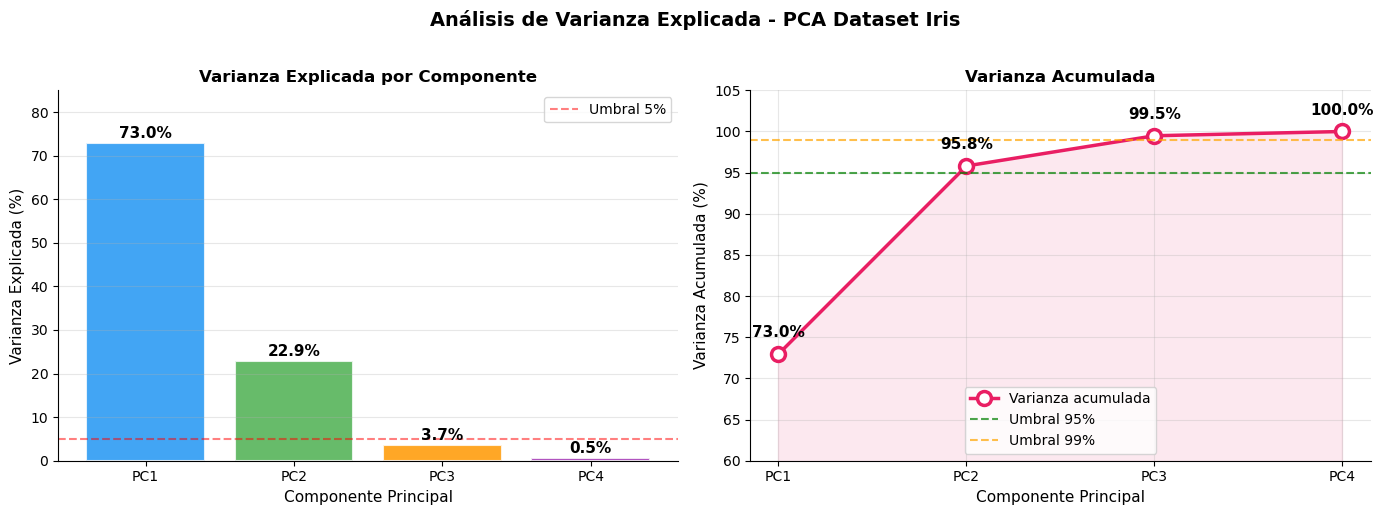

In [26]:
# ============================================================
# SCREE PLOT - VARIANZA EXPLICADA POR COMPONENTE 
# ============================================================
# Eje X: PC1, PC2, PC3, PC4
# Eje Y: varianza explicada/eigenvalores asociados por cada componente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Varianza Explicada - PCA Dataset Iris', fontsize=14, fontweight='bold', y=1.02)

componentes = ['PC1', 'PC2', 'PC3', 'PC4']
varianza_ind = pca_full.explained_variance_ratio_ * 100
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100
colores_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ── Gráfica 1: Varianza individual ──
ax1 = axes[0]
bars = ax1.bar(componentes, varianza_ind, color=colores_bar, edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, varianza_ind):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Varianza Explicada por Componente', fontsize=12, fontweight='bold')
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=11)
ax1.set_ylim(0, 85)
ax1.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Gráfica 2: Varianza acumulada ──
ax2 = axes[1]
ax2.plot(componentes, varianza_acum, 'o-', color='#E91E63', linewidth=2.5,
         markersize=10, markerfacecolor='white',
         markeredgewidth=2.5, label='Varianza acumulada')
ax2.fill_between(range(len(componentes)), varianza_acum, alpha=0.1, color='#E91E63')
for i, val in enumerate(varianza_acum):
    ax2.annotate(f'{val:.1f}%', (componentes[i], val),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=11, fontweight='bold')
ax2.axhline(y=95, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral 95%')
ax2.axhline(y=99, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral 99%')
ax2.set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
ax2.set_xlabel('Componente Principal', fontsize=11)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=11)
ax2.set_ylim(60, 105)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('PCA_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Paso 9: Gráfica Heatmap de Loadings

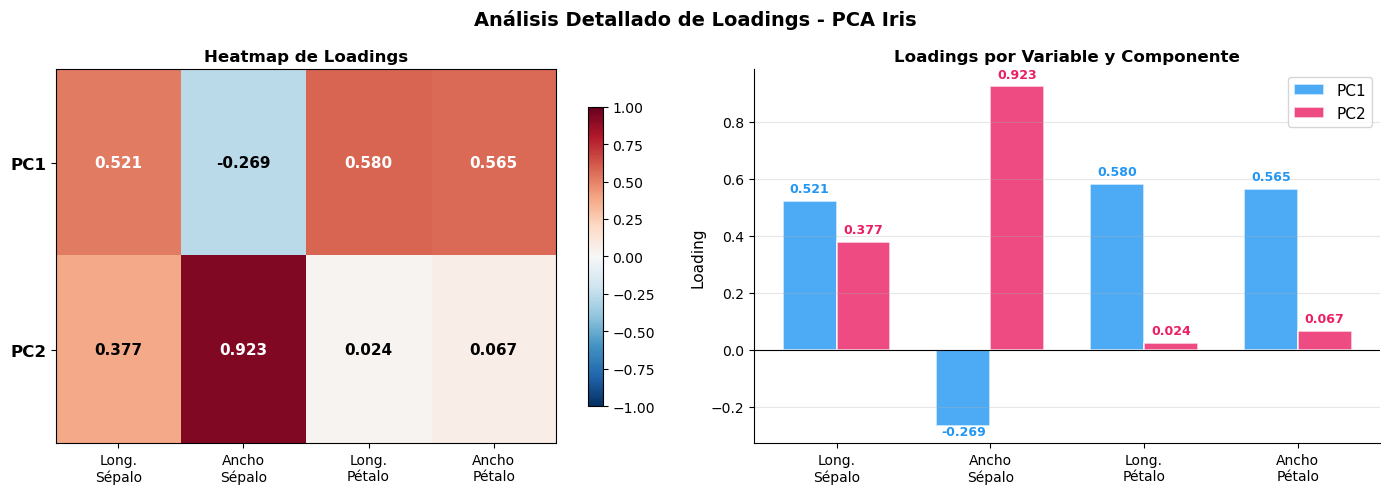

In [67]:
# ============================================================
# HEATMAP DE LOADINGS - VISUALIZACIÓN ADICIONAL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis Detallado de Loadings - PCA Iris', fontsize=14, fontweight='bold')

# ── Heatmap de loadings ──
import matplotlib.colors as mcolors

nombres_cortos = ['Long.\nSépalo', 'Ancho\nSépalo',
                  'Long.\nPétalo', 'Ancho\nPétalo']

im = axes[0].imshow(loadings, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(features)))
axes[0].set_xticklabels(nombres_cortos, fontsize=10)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['PC1', 'PC2'], fontsize=12, fontweight='bold')
axes[0].set_title('Heatmap de Loadings', fontsize=12, fontweight='bold')

# Anotar valores
for i in range(loadings.shape[0]):
    for j in range(loadings.shape[1]):
        val = loadings[i, j]
        color_txt = 'white' if abs(val) > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color_txt)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# ── Barplot comparativo de loadings ──
x = np.arange(len(features))
width = 0.35

bars1 = axes[1].bar(x - width/2, loadings[0], width, label='PC1',
                    color='#2196F3', alpha=0.8, edgecolor='white', linewidth=1.2)
bars2 = axes[1].bar(x + width/2, loadings[1], width, label='PC2',
                    color='#E91E63', alpha=0.8, edgecolor='white', linewidth=1.2)

# Etiquetas de valor
for bar in bars1:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2, h + (0.02 if h > 0 else -0.04),
        f'{h:.3f}', ha='center', va='bottom', fontsize=9, color='#2196F3', fontweight='bold'
    )
for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2, h + (0.02 if h > 0 else -0.04),
        f'{h:.3f}', ha='center', va='bottom', fontsize=9, color='#E91E63', fontweight='bold'
    )

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres_cortos, fontsize=10)
axes[1].set_ylabel('Loading', fontsize=11)
axes[1].set_title('Loadings por Variable y Componente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('PCA_heatmap_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Paso 10: Mapa de Observaciones (Biplot - Scatter)

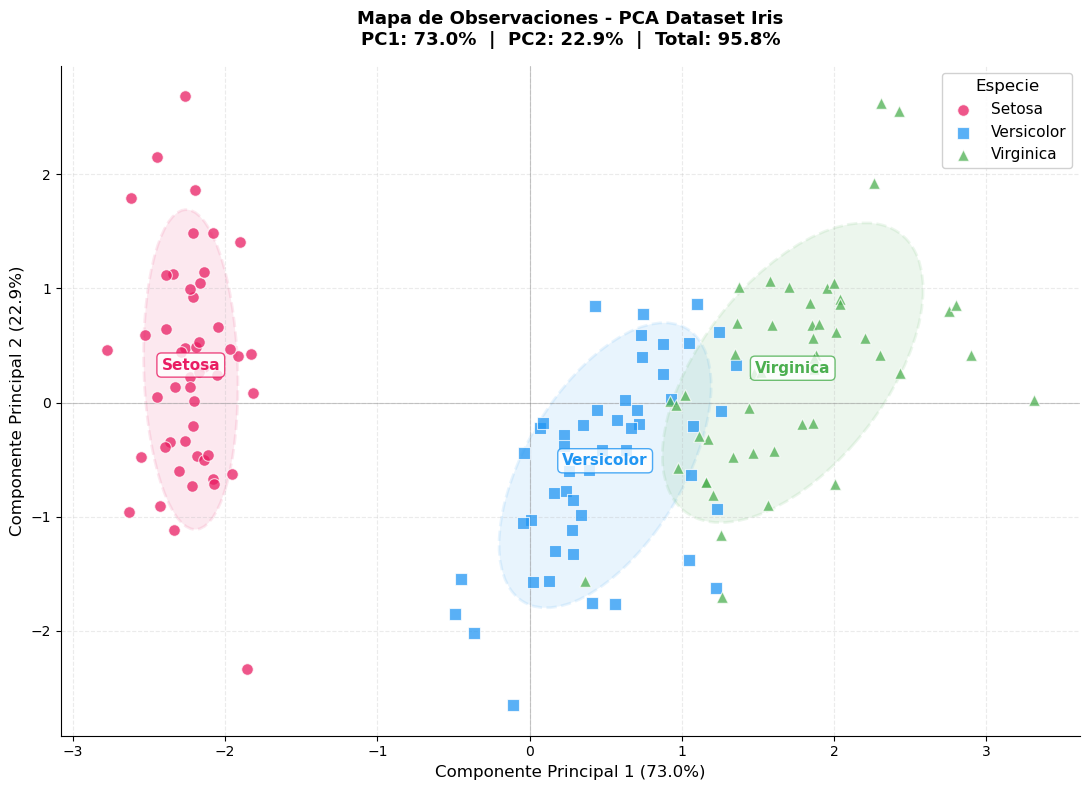

In [68]:
# ============================================================
# MAPA DE OBSERVACIONES - SCATTER PLOT PCA
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))

# Colores y marcadores por especie
especies = ['Setosa', 'Versicolor', 'Virginica']
colores = {'Setosa': '#E91E63', 'Versicolor': '#2196F3', 'Virginica': '#4CAF50'}
marcadores = {'Setosa': 'o', 'Versicolor': 's', 'Virginica': '^'}

# Graficar cada especie
for especie in especies:
    mask = df_pca['variety'] == especie
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=colores[especie],
        marker=marcadores[especie],
        s=70, alpha=0.75, edgecolors='white',
        linewidth=0.8, label=especie, zorder=3
    )

# ── Elipses de confianza por grupo ──
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def plot_confidence_ellipse(x, y, ax, color, n_std=1.5):
    # Dibuja elipse de confianza alrededor de un grupo
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse(
        (0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor=color, alpha=0.10,
        edgecolor=color, linewidth=2,
        linestyle='--'
    )
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

for especie in especies:
    mask = df_pca['variety'] == especie
    plot_confidence_ellipse(
        df_pca.loc[mask, 'PC1'].values,
        df_pca.loc[mask, 'PC2'].values,
        ax, colores[especie]
    )
    # Centroide
    cx = df_pca.loc[mask, 'PC1'].mean()
    cy = df_pca.loc[mask, 'PC2'].mean()
    ax.annotate(
        especie,
        (cx, cy),
        fontsize=11, fontweight='bold',
        color=colores[especie],
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor=colores[especie],
                  alpha=0.8)
    )

# Líneas de referencia
ax.axhline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.4)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.4)

# Etiquetas y formato
ax.set_title(
    'Mapa de Observaciones - PCA Dataset Iris\n'
    f'PC1: {varianza_explicada[0]*100:.1f}%  |  '
    f'PC2: {varianza_explicada[1]*100:.1f}%  |  '
    f'Total: {sum(varianza_explicada)*100:.1f}%',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.1f}%)', fontsize=12)
ax.legend(title='Especie', fontsize=11, title_fontsize=12, framealpha=0.9, loc='upper right')
ax.grid(True, alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('PCA_mapa_observaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Paso 11: Mapa de Factores (Loadings Plot)

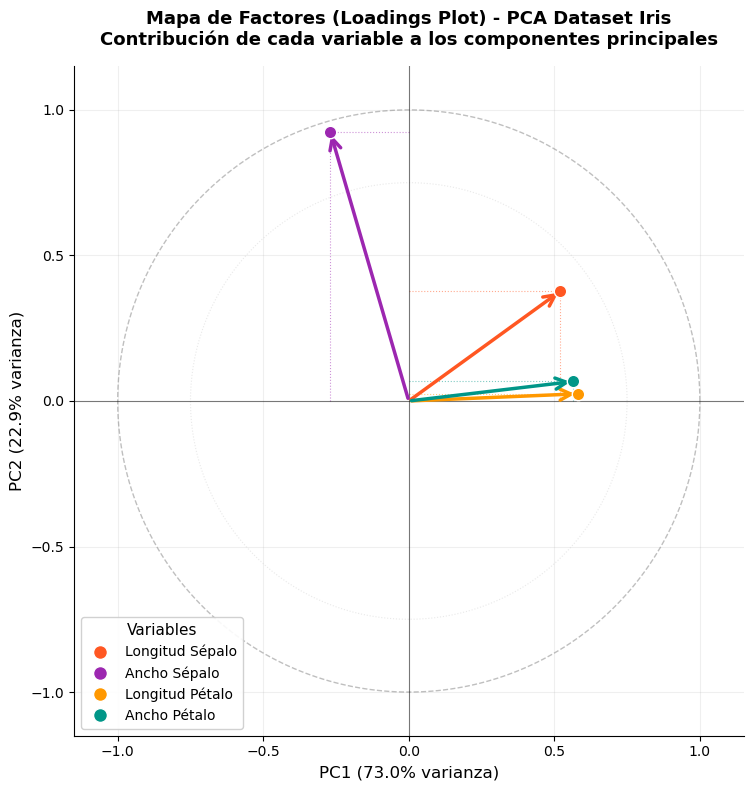


──────────────────────────────────────────────
 INSIGHTS DEL MAPA DE FACTORES
──────────────────────────────────────────────
🟠 Longitud Sépalo  →  Derecha y ligeramente arriba: contribuye fuerte a PC1 (tamaño)

🟣 Ancho Sépalo     →  Arriba casi verticalmente: contribuye casi exclusivamente a PC2 
                        Es casi perpendicular a las otras: poca correlación

🟡 Longitud Pétalo  →  Derecha, casi horizontal: contribuye fuertemente a PC1, casi nada a PC2

🟢 Ancho Pétalo     →  Derecha, casi horizontal: contribuye casi exclusivamente a PC1
                        Paralela a Longitud Pétalo: muy correlacionada con Longitud Pétalo



In [46]:
# ============================================================
# MAPA DE FACTORES - LOADINGS PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 8))

# Nombres cortos para las variables
nombres_vars = {
    'sepal.length': 'Longitud Sépalo',
    'sepal.width':  'Ancho Sépalo',
    'petal.length': 'Longitud Pétalo',
    'petal.width':  'Ancho Pétalo'
}
colores_vars = ['#FF5722', '#9C27B0', '#FF9800', '#009688']

# Círculo unitario de referencia
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.plot(0.75*np.cos(theta), 0.75*np.sin(theta), color='lightgray', linewidth=0.8, linestyle=':', alpha=0.5)

# Graficar vectores de loading
for i, (var, color) in enumerate(zip(features, colores_vars)):
    x_load = loadings[0, i]
    y_load = loadings[1, i]

    # Flecha
    ax.annotate(
        '',
        xy=(x_load, y_load),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle='->', color=color,
            lw=2.5, mutation_scale=20
        )
    )
    # Punto en la punta de la flecha
    ax.scatter(x_load, y_load, s=80, color=color, zorder=5, edgecolors='white', lw=1)

    # Proyección punteada sobre ejes
    ax.plot([x_load, x_load], [0, y_load], color=color, linewidth=0.8, linestyle=':', alpha=0.5)
    ax.plot([0, x_load], [y_load, y_load], color=color, linewidth=0.8, linestyle=':', alpha=0.5)

# Líneas de referencia
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Formato
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect('equal')
ax.set_title(
    'Mapa de Factores (Loadings Plot) - PCA Dataset Iris\n'
    'Contribución de cada variable a los componentes principales',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}% varianza)', fontsize=12)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Leyenda de magnitudes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=c, markersize=10,
           label=list(nombres_vars.values())[i])
    for i, c in enumerate(colores_vars)
]
ax.legend(handles=legend_elements, title='Variables', fontsize=10, title_fontsize=11, loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.savefig('PCA_mapa_factores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
──────────────────────────────────────────────
 INSIGHTS DEL MAPA DE FACTORES
──────────────────────────────────────────────
🟠 Longitud Sépalo  →  Derecha y ligeramente arriba: contribuye fuerte a PC1 (tamaño)

🟣 Ancho Sépalo     →  Arriba casi verticalmente: contribuye casi exclusivamente a PC2 
                        Es casi perpendicular a las otras: poca correlación

🟡 Longitud Pétalo  →  Derecha, casi horizontal: contribuye fuertemente a PC1, casi nada a PC2

🟢 Ancho Pétalo     →  Derecha, casi horizontal: contribuye casi exclusivamente a PC1
                        Paralela a Longitud Pétalo: muy correlacionada con Longitud Pétalo
""")

# Paso 12: Gráfica Combinada (Biplot Completo)

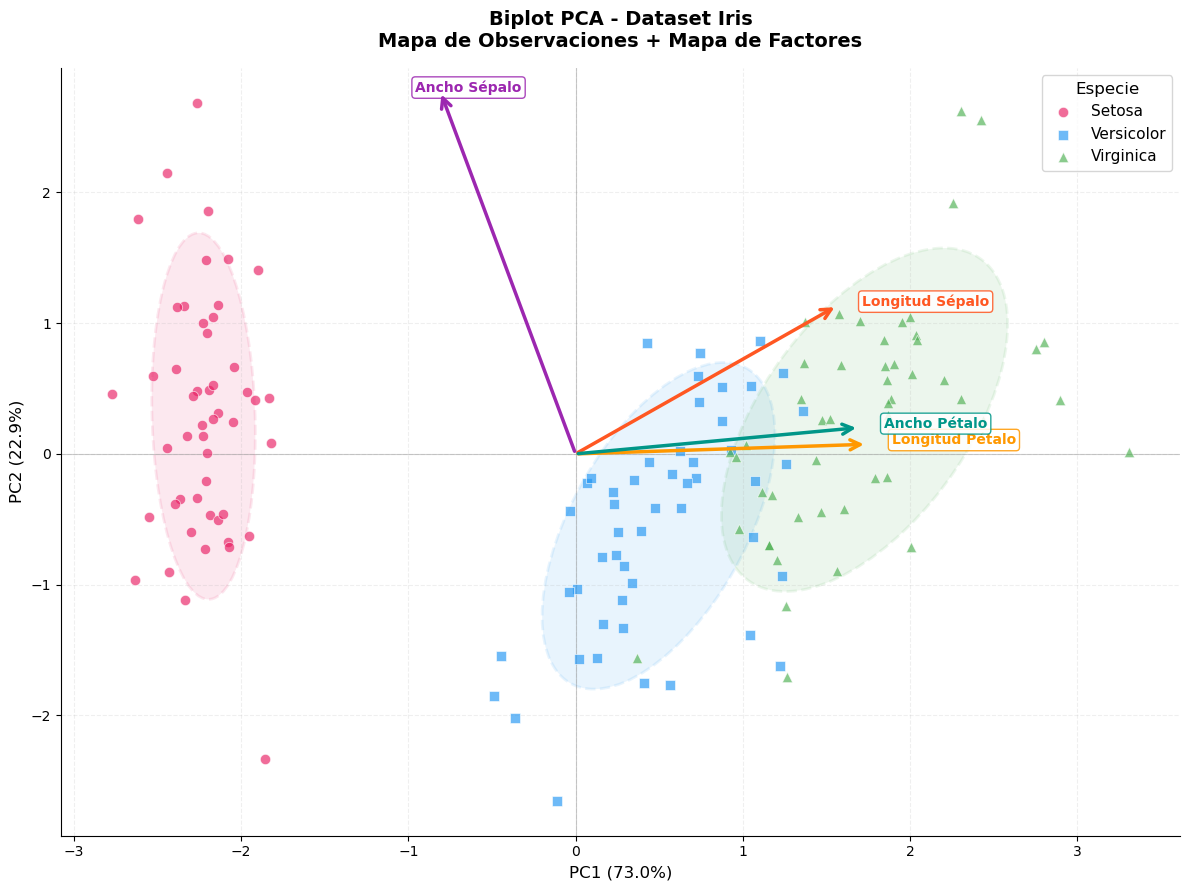

In [48]:
# ============================================================
# BIPLOT COMPLETO: OBSERVACIONES + FACTORES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 9))

# ── Scatter de observaciones ──
for especie in especies:
    mask = df_pca['variety'] == especie
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=colores[especie],
        marker=marcadores[especie],
        s=55, alpha=0.65,
        edgecolors='white', linewidth=0.6,
        label=especie, zorder=3
    )
    plot_confidence_ellipse(
        df_pca.loc[mask, 'PC1'].values,
        df_pca.loc[mask, 'PC2'].values,
        ax, colores[especie]
    )

# ── Vectores de loadings (escalados) ──
escala = 3.0   # Factor de escala para visualización

for i, (var, color) in enumerate(zip(features, colores_vars)):
    x_load = loadings[0, i] * escala
    y_load = loadings[1, i] * escala

    ax.annotate(
        '',
        xy=(x_load, y_load),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle='->', color=color,
            lw=2.5, mutation_scale=18
        ),
        zorder=5
    )
    offset_x = 0.15 if x_load > 0 else -0.15
    ax.text(
        x_load + offset_x, y_load, nombres_vars[var], fontsize=10, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor=color, linewidth=1)
    )

# Líneas de referencia
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
ax.axvline(0, color='gray', linewidth=0.8, alpha=0.4)

# Formato
ax.set_title(
    'Biplot PCA - Dataset Iris\n'
    'Mapa de Observaciones + Mapa de Factores',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}%)', fontsize=12)
ax.legend(title='Especie', fontsize=11, title_fontsize=12, loc='upper right')
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('PCA_biplot_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# Paso 13: Verificación de Casos Específicos

In [63]:
# ============================================================
# VERIFICACIÓN DE CASOS ESPECÍFICOS EN EL DATAFRAME
# ============================================================

print('=' * 65)
print(" ANÁLISIS DE CASOS ESPECÍFICOS")
print('=' * 65)

# ── Caso 1: Observación más extrema en PC1 positivo ──
idx_max_pc1 = df_pca['PC1'].idxmax()
print(f"\n CASO 1 - Mayor valor en PC1 (flor más 'grande'):")
print("─" * 57)
print(df_pca.loc[idx_max_pc1].to_frame().T.round(4).to_string())
print(f"\n   PC1={df_pca.loc[idx_max_pc1,'PC1']:.4f}")
print(f"      → Valores grandes en pétalo y sépalo → Especie grande = Virginica")

# ── Caso 2: Observación más extrema en PC1 negativo ──
idx_min_pc1 = df_pca['PC1'].idxmin()
print(f"\n CASO 2 - Menor valor en PC1 (flor más 'pequeña'):")
print("─" * 57)
print(df_pca.loc[idx_min_pc1].to_frame().T.round(4).to_string())
print(f"\n   PC1={df_pca.loc[idx_min_pc1,'PC1']:.4f}")
print(f"      → Valores pequeños en pétalo y sépalo → Especie pequeña = Setosa")

# ── Caso 3: Mayor valor en PC2 ──
idx_max_pc2 = df_pca['PC2'].idxmax()
print(f"\n CASO 3 - Mayor valor en PC2 (mayor ancho de sépalo):")
print("─" * 57)
print(df_pca.loc[idx_max_pc2].to_frame().T.round(4).to_string())
print(f"\n   PC2={df_pca.loc[idx_max_pc2,'PC2']:.4f}")
print(f"      → Valores pequeños muy grande = outlier visible en la gráfica")

# ── Caso 4: Punto de frontera Versicolor/Virginica ──
print(f"\n CASO 4 - Casos en la frontera Versicolor/Virginica:")
print("─" * 57)
frontera = df_pca[
    (df_pca['variety'].isin(['Versicolor', 'Virginica'])) & (df_pca['PC1'].between(0.8, 1.5))].sort_values(['variety', 'PC1'])  
print(frontera.round(4).to_string())
# Conteo por especie para confirmar el solapamiento
print("\n Conteo por especie en la zona de solapamiento entre Versicolor y Virginica:")
print(frontera['variety'].value_counts())

# ── Resumen estadístico por especie ──
print(f"\n ESTADÍSTICAS PCA POR ESPECIE:")
print("─" * 45)
resumen = df_pca.groupby('variety')[['PC1', 'PC2']].agg(['mean', 'std'])
print(resumen.round(4))

 ANÁLISIS DE CASOS ESPECÍFICOS

 CASO 1 - Mayor valor en PC1 (flor más 'grande'):
─────────────────────────────────────────────────────────
          PC1       PC2    variety sepal.length sepal.width petal.length petal.width
118  3.310696  0.017781  Virginica          7.7         2.6          6.9         2.3

   PC1=3.3107
      → Valores grandes en pétalo y sépalo → Especie grande = Virginica

 CASO 2 - Menor valor en PC1 (flor más 'pequeña'):
─────────────────────────────────────────────────────────
         PC1       PC2 variety sepal.length sepal.width petal.length petal.width
22 -2.774345  0.458344  Setosa          4.6         3.6          1.0         0.2

   PC1=-2.7743
      → Valores pequeños en pétalo y sépalo → Especie pequeña = Setosa

 CASO 3 - Mayor valor en PC2 (mayor ancho de sépalo):
─────────────────────────────────────────────────────────
         PC1       PC2 variety sepal.length sepal.width petal.length petal.width
15 -2.262215  2.686284  Setosa          5.7       

# Paso 14: Conclusiones y Análisis Final

─────────────────────────────────────────────────────────────────
###  1. VARIANZA EXPLICADA (PC1 + PC2)
─────────────────────────────────────────────────────────────────

  • PC1 explica el 72.96% de la varianza total
  
  • PC2 explica el 22.85% de la varianza total
  
  • JUNTOS explican el 95.81% de la varianza total

  Con solo 2 componentes se conserva el 95.81% de la información original, logrando una reducción 
  eficiente de 4 dimensiones a 2 sin pérdida significativa de datos.

─────────────────────────────────────────────────────────────────
###  2. INTERPRETACIÓN DE COMPONENTES
─────────────────────────────────────────────────────────────────

  ✦ PC1 = "Tamaño general de la flor"
  
    ⦁ Cargas altas POSITIVAS en:
      Long. Pétalo +0.580 (mayor peso)
      Ancho Pétalo +0.565
      Long. Sépalo +0.521
    ⦁ Carga NEGATIVA en: Ancho Sépalo -0.269 (pequeña contribución inversa)
    
      Flores con PC1 alto tienen pétalos y sépalos grandes (Virginica). 
      Flores con PC1 bajo son pequeñas (Setosa).

  ✦ PC2 = "Ancho del sépalo"

    ⦁ Carga alta POSITIVA en: Ancho Sépalo +0.923 (domina casi exclusivamente)
    ⦁ PC2 captura la variación del ancho del sépalo de forma independiente al tamaño general de la flor. 
  
      Flores con PC2 alto tienen sépalos notablemente anchos.

─────────────────────────────────────────────────────────────────
###  3. MAPA DE OBSERVACIONES vs MAPA DE FACTORES
─────────────────────────────────────────────────────────────────

  Al superponer ambos mapas en el Biplot se observa:

  ✦ SETOSA (PC1 promedio = -2.22):
     Grupo completamente separado en el extremo izquierdo.
     Los vectores de Longitud y Ancho de Pétalo apuntan en dirección OPUESTA a Setosa, 
     confirmando que esta especie tiene los pétalos más pequeños del dataset.

  ✦ VIRGINICA (PC1 promedio = +1.73):
     Los vectores de Longitud Pétalo, Ancho Pétalo yLongitud Sépalo apuntan hacia el grupo Virginica,
     confirmando que posee las flores de mayor tamaño.

  ✦ VERSICOLOR (PC1 promedio = +0.50):
     Se ubica entre Setosa y Virginica en el eje PC1.
     Presenta solapamiento con Virginica en la zona PC1 = 0.8 a 1.5, 
     donde ambas especies comparten características morfológicas similares.

  ✦ El vector Ancho Sépalo es casi PERPENDICULAR a los vectores de pétalo, 
    confirmando que actúa de forma independiente (capturado por PC2, no por PC1).

─────────────────────────────────────────────────────────────────
###  4. CASOS ESPECÍFICOS VERIFICADOS EN EL DATAFRAME
─────────────────────────────────────────────────────────────────

  ✦ Obs. #118 (Virginica): PC1 = +3.31
     petal.length = 6.9 cm → la más grande del dataset.
     Aparece en el extremo derecho del gráfico, más allá de la elipse de su grupo: outlier de Virginica.

  ✦ Obs. #22 (Setosa): PC1 = -2.77
     petal.length = 1.0 cm → la más pequeña del dataset.
     Aparece en el extremo izquierdo dentro del grupo Setosa, con el pétalo más corto registrado.

  ✦ Obs. #15 (Setosa): PC2 = +2.69
     sepal.width = 4.4 cm → el sépalo más ancho del dataset. 
     Aparece aislada en la parte superior del gráfico, fuera de la nube principal de Setosas.
     Es el outlier más visible en el eje PC2.

  ✦ Zona de solapamiento Versicolor / Virginica:
     En el rango PC1 = 0.8 a 1.5 conviven:
       13 flores de Versicolor
       18 flores de Virginica
     En esta región sus medidas morfológicas son tan similares que el PCA no logra separarlas, lo que
     explica por qué ambas especies son más difíciles de clasificar automáticamente que Setosa.

─────────────────────────────────────────────────────────────────
###  5. NOTA SOBRE CALIDAD DEL DATASET
─────────────────────────────────────────────────────────────────

  Se detectó 1 fila duplicada (Obs. #101 y #142):
  
    sepal.length=5.8, sepal.width=2.7,
    petal.length=5.1, petal.width=1.9, Virginica
    
  Ambas reciben el mismo valor de PC1=1.158 y PC2=-0.699,
  lo que es consistente: datos idénticos → misma posición en el espacio PCA.